Found 286 valley-arm points


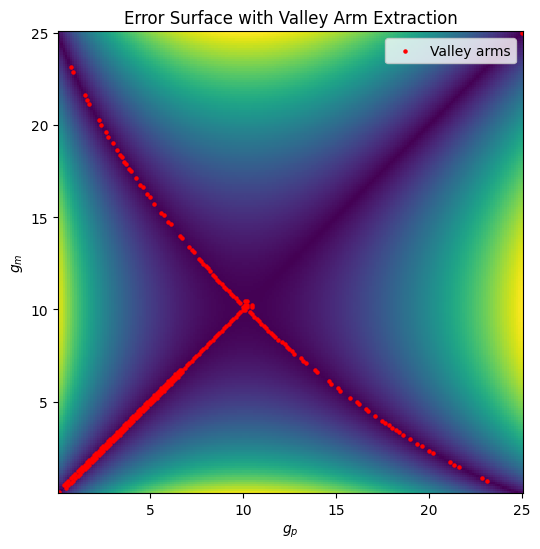

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from numpy.linalg import eig

# ---- Parameters ----
g_min, g_max = 0.1, 25
N = 200
tau = 1e6
beta = 1 / g_max

def nu(g):
    g_rel = (g - g_min) / (g_max - g_min)
    return -0.0155 * np.log(g_rel + 0.00762) + 0.0244

def f(g):
    return g * tau**(-nu(g))

# amplification exponent
nu_amp = nu(g_max)

# ---- Create grid ----
gp = np.linspace(g_min, g_max, N)
gm = np.linspace(g_min, g_max, N)
GP, GM = np.meshgrid(gp, gm)

# ---- Compute error surface ----
error = np.abs((GP - GM) * beta - ((f(GP) - f(GM)) * beta * tau**nu_amp))

# ---- Smooth for stability ----
error_smooth = gaussian_filter(error, sigma=0.01)

# ---- Compute gradients ----
dE_dgm, dE_dgp = np.gradient(error_smooth, gm, gp)

# ---- Compute Hessian components ----
d2E_dgm2, d2E_dgm_dgp = np.gradient(dE_dgm, gm, gp)
d2E_dgp_dgm, d2E_dgp2   = np.gradient(dE_dgp, gm, gp)

# ---- Directional derivatives ----
L_q  = np.zeros_like(error)
L_qq = np.zeros_like(error)

for i in range(N):
    for j in range(N):
        H = np.array([[d2E_dgp2[i,j],   d2E_dgp_dgm[i,j]],
                      [d2E_dgp_dgm[i,j], d2E_dgm2[i,j]]])
        vals, vecs = eig(H)
        minor_vec = vecs[:, np.argmin(np.abs(vals))]
        grad = np.array([dE_dgp[i,j], dE_dgm[i,j]])
        L_q[i,j]  = grad.dot(minor_vec)
        L_qq[i,j] = minor_vec.dot(H.dot(minor_vec))

# ---- Identify valley arms ----
tol = np.percentile(np.abs(L_q), 5)  # loosen threshold
mask = (np.abs(L_q) < tol) & (L_qq > 0)

print(f"Found {mask.sum()} valley-arm points")

# ---- Plotting ----
plt.figure(figsize=(6,6))
plt.pcolormesh(GP, GM, error, shading='auto', cmap='viridis')
if mask.sum()>0:
    plt.scatter(GP[mask], GM[mask], s=5, c='red', label='Valley arms')
plt.xlabel('$g_p$'); plt.ylabel('$g_m$')
plt.title('Error Surface with Valley Arm Extraction')
plt.legend()
plt.show()
